# Applications of Clustering Algorithms

## Example 1: K-Means Clustering

Use the K-means algorithm and Euclidean distance metric to partition $8$ two-dimensional data points into $K = 3$ disjoint clusters:

$$
\begin{aligned}
A_1 &= (2, 11), & A_2 &= (1, 5), & A_3 &= (7, 4), & A_4 &= (4, 8), \\
A_5 &= (7, 6), & A_6 &= (5, 4), & A_7 &= (0, 2), & A_8 &= (3, 8)
\end{aligned}
$$

Initial seed cluster centers (selected directly from dataset points):
$$
\text{Seed1} = A_1 = (2, 11), \quad \text{Seed2} = A_4 = (4, 8), \quad \text{Seed3} = A_7 = (0, 2)
$$

**Task 1.1: Input data**

To do: replace `...` below to complete the task

Input the above data points and the initial cluster centers as initial centroids.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from scipy.spatial import ConvexHull

# Task 1.1.1: Input the data points
points = np.array([
    [2, 11], [1, 5], [7, 4], [4, 8],
    [7, 6], [5, 4], [0, 2], [3, 8]
])
labels = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']

# Task 1.1.2: Input the initial centroids
centroids = np.array([
    [2, 11], [4, 8], [0, 2]
])

**Task 1.2: Define distance function**

To do: replace `...` below to complete the task

Define the function `euclidean_distance(a, b)`, which calculates the euclidean distance between points `a` and `b`

**Hint:**
- `np.linalg.norm(v)` returns norm/ modulus/ magnitude of a vector `v`

In [ ]:
def euclidean_distance(a, b):
    """ Compute Euclidean L2 distance between two 2D vectors """
    return np.linalg.norm(a - b)

**Task 1.3: Define `assign_clusters` function for assigning points to clusters**

To do: replace `...` below to complete the task

Define the function `assign_clusters(points, centroids)`:
 * **Inputs:**
    * `points`: A NumPy array of data points
    * `centroids`: A NumPy array of cluster centers
 * **Initialization:** Create a list of empty lists called `clusters`, with one empty sublist for each centroid.
 * **Iteration over points:** For each point in `points`:
    * Compute the Euclidean distance from the **current point** to **every centroid** using a list comprehension
    * Find the index `cluster_idx` of the centroid with the minimum distance
    * Append the index `idx` of the current point to the corresponding cluster sublist
 * **Output:** Returns `clusters`, a list of lists where `clusters[i]` contains the $\fbox{indices}$ of all points closest to `centroids[i]`

 **Hints:**
 - `np.argmin(a)` returns the indices of the minimum values along an axis
 - `list.append(item)` appends a new item `item` into `list`

In [ ]:
def assign_clusters(points, centroids):
    # Task 1.3.1: Initialization
    clusters = [[] for _ in centroids]

    # Task 1.3.2: Iteration over points
    for idx, point in enumerate(points):
        distances = [euclidean_distance(point, centroid) for centroid in centroids] # Compute the Euclidean distances between the point and each centroid
        cluster_idx = np.argmin(distances) # Find the index of the minimum of the distances
        clusters[cluster_idx].append(idx) # Append to the list of clusters
    return clusters

**Task 1.4: Define `update_centroids` function for updating centroids**

To do: replace `...` below to complete the task

Define the function `update_centroids(points, clusters)`:
 * **Inputs:**
    * `points`: A NumPy array of data points
   * `clusters`: A list of lists, where each sublist contains the $\fbox{indices}$ of points assigned to a particular cluster (as returned by function `assign_clusters`).
 * **Initialization:** Create an empty list `new_centroids` to store the updated centroid positions.

 * **Iteration over clusters:** For each cluster in `clusters`:
    * Extract the actual points belonging to that cluster
    * Compute the new centroid as the **mean** of those points along the rows
    * Appends this new centroid to `new_centroids`
 * **Output:** Convert the list of new centroids to a NumPy array and returns it

**Hint:**
- `np.mean(list, axis=0)` returns the mean of all elements in `list`

In [ ]:
def update_centroids(points, clusters):
    # Task 1.4.1: Initialization
    new_centroids = []

    # Task 1.4.2: Iteration over clusters
    for cluster in clusters:
        cluster_points = points[cluster] # Extract actual points belonging to that cluster
        new_centroid = np.mean(cluster_points, axis=0) # Compute the new centroid
        new_centroids.append(new_centroid) # Append the new centroid to new_centroids
    return np.array(new_centroids)

**Task 1.5: Define `plot_clusters` function for plotting clusters**

In [ ]:
def plot_clusters(points, clusters, centroids, iteration):
    """Plot current cluster state at each iteration step"""
    colors = plt.colormaps.get_cmap("tab10")
    plt.figure(figsize=(6, 5))
    for i, cluster in enumerate(clusters):
        cluster_points = points[cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i+1}', color=colors(i))
        plt.scatter(*centroids[i], color=colors(i), marker='X', s=100, edgecolor='black', label=f'Centroid {i+1}')
        for idx in cluster:
            plt.text(points[idx][0]+0.1, points[idx][1]+0.1, labels[idx], fontsize=9)

        # Draw convex hull boundary
        if len(cluster_points) >= 3:
            hull = ConvexHull(cluster_points)
            for simplex in hull.simplices:
                plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], color=colors(i), linestyle='--', linewidth=1.5)

    plt.title(f'K-Means Clustering with Boundaries - Iteration {iteration}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend(loc='best')
    plt.grid(True)
    plt.show()

**Task 1.6: K-Means Iteration Loop**

To do: replace `...` below to complete the task

Run K-Means Algorithm for $5$ iterations:
  * **Assignment Step:** use `assign_clusters` function to assign each point to the nearest current centroid, producing the list of cluster indices
  * **Plotting:** use `plot_clusters` function to visualize the current clustering state
  * **Update Step:** use `update_clusters` function to compute new centroids
  * **Convergence Check:** Use `np.allclose` function to check if the centroids have stopped changing significantly
      * If true, breaks out of the loop early
  * **Update Centroids:** If not converged, set `centroids` as `new_centroids` for the next iteration

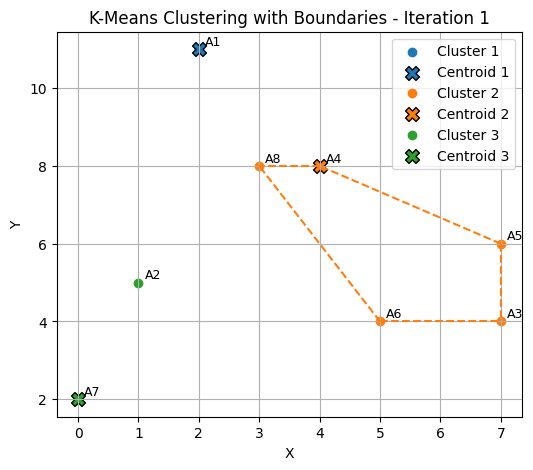

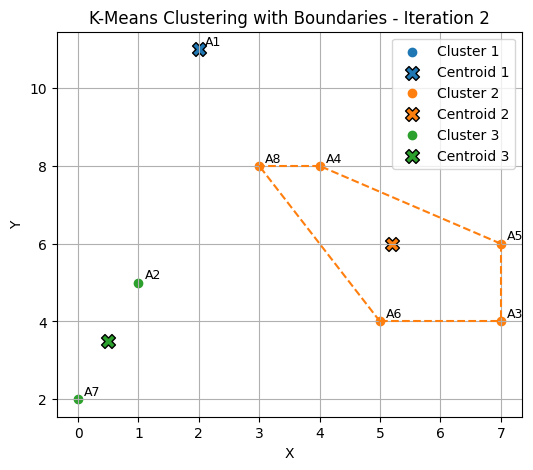

Converged at iteration 2


In [ ]:
# Run K-means for 5 iterations
for i in range(1, 6):
    clusters = assign_clusters(points, centroids) # Assignment Step
    plot_clusters(points, clusters, centroids, i) # Plotting
    new_centroids = update_centroids(points, clusters) # Update Step
    if np.allclose(centroids, new_centroids): # Convergence Check
        print(f'Converged at iteration {i}')
        break
    centroids = new_centroids # Update Centroids

## Example 2: Nearest Neighbor Clustering with Distance Threshold

**Dataset:**

The dataset contains $8$ two-dimensional sample points:

$$
\begin{aligned}
A_1 &= (2, 11), & A_2 &= (1, 5), & A_3 &= (7, 4), & A_4 &= (4, 8), \\
A_5 &= (7, 6), & A_6 &= (5, 4), & A_7 &= (0, 2), & A_8 &= (3, 8)
\end{aligned}
$$

Clustering Hyperparameter Threshold: $ t = 5 $

**Task 2.1: Input data and Initialize clusters**

To do: replace `...` below to complete the tasks

1. Input the above data points and  the threshold
2. Initialize the first clusters as cluster $0$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from scipy.spatial import ConvexHull

# Task 2.1.1: Define the Dataset
points = np.array([
    [2, 11],  # A1
    [1, 5],   # A2
    [7, 4],   # A3
    [4, 8],   # A4
    [7, 6],   # A5
    [5, 4],   # A6
    [0, 2],   # A7
    [3, 8]    # A8
])
labels = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']

threshold = 5

# Task 2.1.2: Initialize clusters
clusters = [[0]]  # Start with A1 in cluster 0

**Task 2.2: Define distance function**

To do: replace `...` below to complete the task

Define the function `euclidean_distance(a, b)`, which calculates the euclidean distance between points `a` and `b`

In [ ]:
def euclidean_distance(a, b):
    """ Compute Euclidean L2 distance between two 2D vectors """
    return np.linalg.norm(a - b)

**Task 2.3: Define `find_nearest_cluster` function for finding nearest cluster**

To do: replace `...` below to complete the task

Define the function `find_nearest_cluster(point_idx, clusters)`:
 * **Inputs:**
    * `point_idx`: The index of the query point in points
    * `clusters`: The current list of clusters (each a list of point indices).
 * **Initialization:**
    * Set `min_dist` to infinity
    * Set `nearest_cluster` to `None`
 * **Iteration:**
    * Loops over each cluster to get both the index (`cluster_idx`) and the cluster list (`cluster`)
    * For each member index (`member_idx`) in the current cluster:
        * Computes the Euclidean distance between `points[point_idx]` and `points[member_idx]`
        * If `dist` is smaller than the current `min_dist`, updates `min_dist` and sets `nearest_cluster` to `cluster_idx`
 * **Output:** Returns two outputs `min_dist, nearest_cluster`

**Hint:**
- `float('inf')` represents infinity value

In [ ]:
def find_nearest_cluster(point_idx, clusters):
    """
    Find minimal distance from target point to all clustered points,
    return min distance and index of nearest cluster
    """
    # Task 2.3.1: Initialization
    min_dist = float('inf')
    nearest_cluster = None

    # Task 2.3.2: Iteration over clusters
    for cluster_idx, cluster in enumerate(clusters):
        # Loop over each member of the current cluster
        for member_idx in cluster:
            dist = euclidean_distance(points[point_idx], points[member_idx]) # Compute the distance
            if dist < min_dist: # Check if dist < min_dist
                min_dist = dist # Update min_dist
                nearest_cluster = cluster_idx # Update nearest_cluster
    return min_dist, nearest_cluster

**Task 2.4: Define `plot_clusters` function for plotting clusters**

In [ ]:
def plot_clusters(clusters, iteration):
    """Plot current cluster state at each iteration step"""
    colors = plt.colormaps.get_cmap("tab10")
    plt.figure(figsize=(6, 5))
    for i, cluster in enumerate(clusters):
        cluster_points = points[cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i+1}', color=colors(i))
        for idx in cluster:
            plt.text(points[idx][0]+0.1, points[idx][1]+0.1, labels[idx], fontsize=9)

        # Draw convex hull boundary
        if len(cluster_points) >= 3:
            hull = ConvexHull(cluster_points)
            for simplex in hull.simplices:
                plt.plot(cluster_points[simplex, 0], cluster_points[simplex, 1], color=colors(i), linestyle='--', linewidth=1.5)

    plt.title(f'Nearest Neighbor Clustering - Step {iteration}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.xlim(-0.25, 8.25)
    plt.ylim(1.75, 11.25)
    plt.legend()
    plt.grid(True)
    plt.show()

**Task 2.5: Clustering Process Loop**

To do: replace `...` below to complete the task

Finish the Clustering Process:

For each point in `points` starting at the second point:
  * **Identify nearest neighbor**: use `find_nearest_cluster` function to get the minimum distance to the nearest cluster and that cluster's 0-based index
  * **Decision:**
    * If `dist < threshold`, appends the current point's index `i` to `clusters[nearest]` (joins the cluster)
    * Else, appends a new list `[i]` to `clusters` (creates a new cluster)
  * **Plotting:** use `plot_clusters` function to visualize the updated clusters at this step


Step 2: Processing point A2
  Minimum distance to existing clusters = 6.08
  Nearest existing cluster index = 1
  Result: Create new Cluster 2 for A2



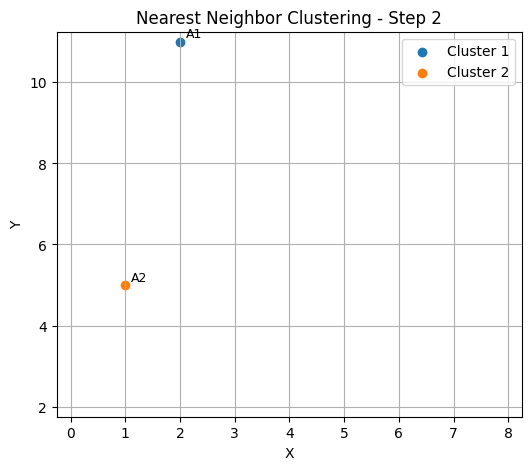


Step 3: Processing point A3
  Minimum distance to existing clusters = 6.08
  Nearest existing cluster index = 2
  Result: Create new Cluster 3 for A3



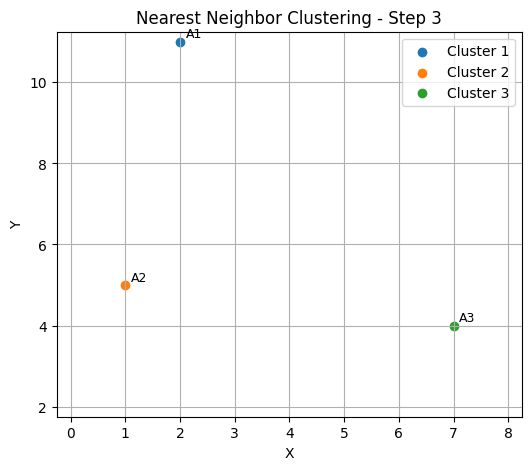


Step 4: Processing point A4
  Minimum distance to existing clusters = 3.61
  Nearest existing cluster index = 1
  Result: Assign A4 to Cluster 1



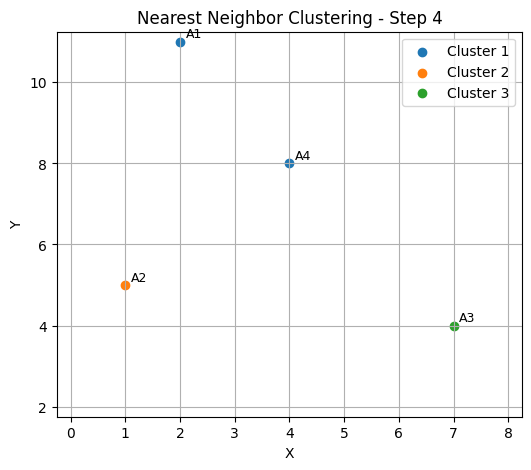


Step 5: Processing point A5
  Minimum distance to existing clusters = 2.00
  Nearest existing cluster index = 3
  Result: Assign A5 to Cluster 3



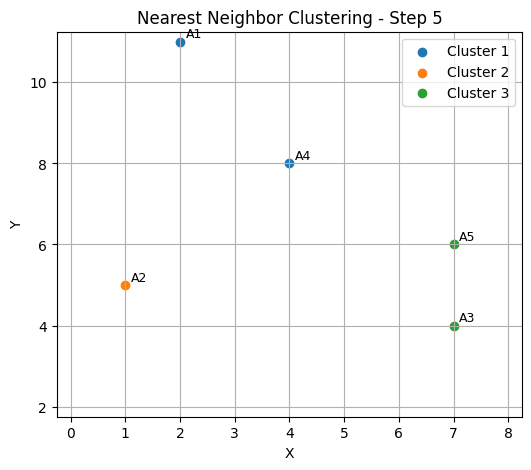


Step 6: Processing point A6
  Minimum distance to existing clusters = 2.00
  Nearest existing cluster index = 3
  Result: Assign A6 to Cluster 3



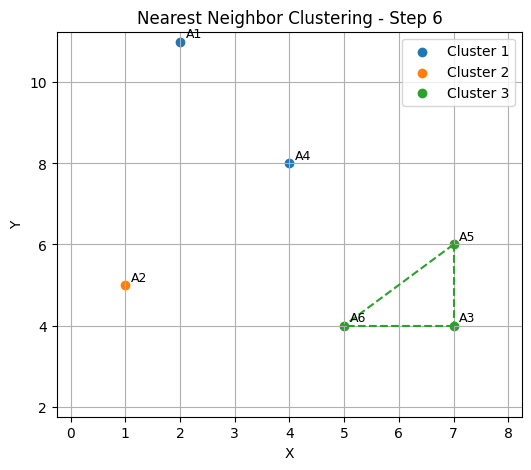


Step 7: Processing point A7
  Minimum distance to existing clusters = 3.16
  Nearest existing cluster index = 2
  Result: Assign A7 to Cluster 2



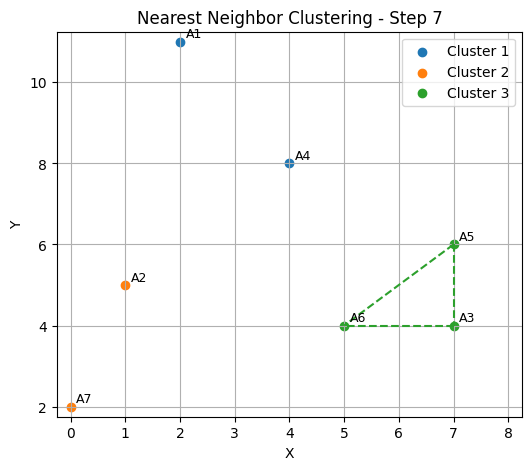


Step 8: Processing point A8
  Minimum distance to existing clusters = 1.00
  Nearest existing cluster index = 1
  Result: Assign A8 to Cluster 1



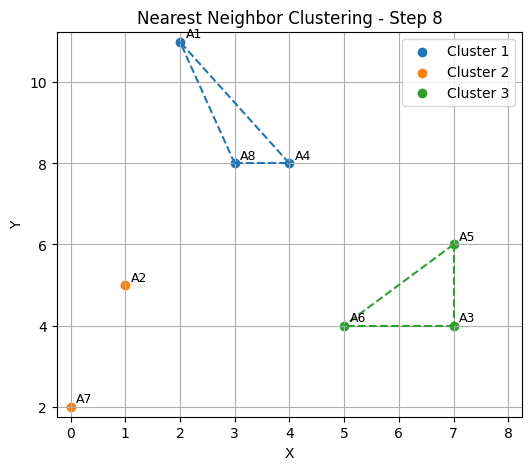

In [ ]:
# Task 2.5: Clustering process
for i in range(1, len(points)): # Loop over each point in points starting at the second point
    dist, nearest = find_nearest_cluster(i, clusters) # Identify nearest neighbor
    current_label = labels[i]
    print(f"\nStep {i+1}: Processing point {current_label}")
    print(f"  Minimum distance to existing clusters = {dist:.2f}")
    print(f"  Nearest existing cluster index = {nearest+1}")

    if dist < threshold: # Check the min distance
        clusters[nearest].append(i) # Append the index to the cluster
        print(f"  Result: Assign {current_label} to Cluster {nearest+1}\n")
    else:
        clusters.append([i]) # Create a new cluster
        print(f"  Result: Create new Cluster {len(clusters)} for {current_label}\n")
    plot_clusters(clusters, i+1) # Plotting

**Task 2.6: Print the final result**

In [ ]:
# Task 2.6: Print the Final result
print("Final Clusters:")
for i, cluster in enumerate(clusters):
    members = [labels[idx] for idx in cluster]
    print(f"Cluster {i+1}: {members}")

Final Clusters:
Cluster 1: ['A1', 'A4', 'A8']
Cluster 2: ['A2', 'A7']
Cluster 3: ['A3', 'A5', 'A6']


## Example 3: K-Medoids Clustering Algorithm (PAM: Partitioning Around Medoids)

**Dataset**

$$
\begin{array}{|c|c|}
\hline
\textrm{Point} & \textrm{Coordinates} \\
\hline
A_1 & (2, 6) \\
A_2 & (3, 8) \\
A_3 & (4, 7) \\
A_4 & (6, 2) \\
A_5 & (6, 4) \\
A_6 & (7, 3) \\
A_7 & (7, 4) \\
A_8 & (8, 5) \\
A_9 & (7, 6) \\
A_10 & (3, 4) \\
\hline
\end{array}
$$

**Initial Medoids**
$$
\begin{array}{|c|c|}
\hline
\textrm{Point} & \textrm{Coordinates} \\
\hline
M_1 \: (A_{10}) & (3, 4) \\
M_2 \: (A_6) & (7, 3) \\
\hline
\end{array}
$$

Target number of clusters: $K = 2$

**Task 3.1: Implement the Manhattan Distance Function**

To do: replace `...` below to complete the task

Define function `manhattan_distance(a, b)` that computes the Manhattan distance between two points `a` and `b`.

**Hint:**
- The Manhattan distance between two points $P = (p_1, p_2)$ and $Q = (q_1, q_2)$ is defined by $$d(P,Q) = |p_1 - q_1| + |p_2 - q_2|$$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Manhattan distance function
def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

**Task 3.2: Implement Cluster Assignment and Cost Calculation**

To do: replace `...` below to complete the task

Define function `assign_clusters(points, medoids)` that assigns each data point in points to the nearest medoid in medoids using the Manhattan distance and calculates clustering cost
  * **Input:**
    * `points`: A NumPy array of data points
    * `medoids`: A NumPy array of medoids

  * **Initialization:**
    * Create a list of empty lists `clusters` (one per medoid) to store the indices of assigned points
    * Initialize `total_cost` to $0$ and `cluster_assignments` as an empty list
    
  * **Iteration:** For each point in `points` (using its index idx and coordinates point):
    * Compute distances to all medoids
    * Find the index `cluster_idx` of the closest medoid using `np.argmin`
    * Append `idx` to the corresponding cluster
    * Append a tuple `(idx + 1, point.tolist(), distances, cluster_idx + 1)` to `cluster_assignments`
    * Add the minimum distance to `total_cost`

  * **Output:** `clusters, total_cost, cluster_assignments`

In [ ]:
# Task 3.2: Assign points to the nearest medoid
def assign_clusters(points, medoids):
    # Task 3.2.1: Initialization
    clusters = [[] for _ in medoids]
    total_cost = 0
    cluster_assignments = []

    # Task 3.2.2: Iteration over points
    for idx, point in enumerate(points):
        distances = [manhattan_distance(point, medoid) for medoid in medoids]   # Compute the Manhattan distnace between the point and each medoid
        cluster_idx = np.argmin(distances)   # Find the index of the minimum of the distances
        clusters[cluster_idx].append(idx)    # Append to the list of clusters
        cluster_assignments.append((idx + 1, point.tolist(), distances, cluster_idx + 1))   # Append a tuple to cluster_assignments
        total_cost += distances[cluster_idx]  # Add the min distance to total_cost
    return clusters, total_cost, cluster_assignments

**Task 3.3: Implement Medoid Swap Optimization**

To do: replace `...` below to complete the task

Define function `try_swaps(points, medoids, current_cost)` that attempts to improve the medoids by swapping each current medoid with every non-medoid point and evaluating the new cost.
  * **Input:**
    * `points`: A NumPy array of points
    * `medoids`: A NumPy array of medoids
    * `current_cost`: A integer which represents the current cost

  * **Initialization:**
    * Copy the current `medoids` to `best_medoids`
    * Set `best_cost` to `current_cost`
    
  * **Iteration:** For each `medoid` index `i` (0 to k-1):

    * For each `point` index `j` (0 to n-1):

      * Skip if `points[j]` is already a medoid
      * Create a temporary copy of `medoids`, replace the `i`-th medoid with `points[j]`.
      * Call function `assign_clusters` to get the new cost
      * If the new cost is lower than `best_cost`, update `best_medoids` and `best_cost`

  * **Output:** `best_medoids, best_cost`

In [ ]:
# Task 3.3: Try swapping medoids and return the best swap
def try_swaps(points, medoids, current_cost):
    # Task 3.3.1: Initialization
    best_medoids = medoids.copy()
    best_cost = current_cost

    # Task 3.3.2: Loop through each medoid and points
    for i in range(len(medoids)):
        for j in range(len(points)):
            if not any(np.array_equal(points[j], m) for m in medoids):  # Check if the point is a medoid
                temp_medoids = medoids.copy()   # Create a temporary copy of medoids
                temp_medoids[i] = points[j]     # Replace the i-th medoid with the points
                _, temp_cost, _ = assign_clusters(points, temp_medoids)     # Get the new cost
                if temp_cost < best_cost:     # Check if the new cost is lower
                    best_medoids = temp_medoids   # Update best_medoids
                    best_cost = temp_cost     # Update best_cost
    return best_medoids, best_cost

**Task 3.4: Implement plotting function for clusters and medoids**

In [ ]:
# Task 3.4: Plot clusters and medoids
def plot_clusters(points, clusters, medoids, iteration, cost):
    colors = ['red', 'blue']
    plt.figure(figsize=(6, 5))
    for i, cluster in enumerate(clusters):
        cluster_points = points[cluster]
        plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f'Cluster {i+1}', color=colors[i])
        plt.scatter(*medoids[i], color=colors[i], marker='X', s=200, edgecolor='black')
    plt.title(f'K-Medoids Clustering - Iteration {iteration}\nTotal Cost: {cost}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.legend()
    plt.grid(True)
    plt.show()

**Task 3.5: Set Up Data Points and Initial Medoids**

To do: replace `...` below to complete the task

Define the dataset and initial medoids as NumPy arrays.

In [ ]:
# Task 3.5.1: Initialize the Data points
points = np.array([
    [2, 6],   # A1
    [3, 8],   # A2
    [4, 7],   # A3
    [6, 2],   # A4
    [6, 4],   # A5
    [7, 3],   # A6
    [7, 4],   # A7
    [8, 5],   # A8
    [7, 6],   # A9
    [3, 4]    # A10
])

# Task 3.5.2: Initial medoids: A10 and A6
medoids = np.array([
    [3, 4],  # A10
    [7, 3]   # A6
])

**Task 3.6: Implement the Main K-Medoids Loop**

To do: replace `...` below to complete the task

Write the main loop to run the k-medoids algorithm until convergence. Start with `iteration = 1`.
Inside the loop:
  * Call function `assign_clusters(points, medoids)` to get `clusters`, `cost`, and `assignments`
  * Call function `plot_clusters(points, clusters, medoids, iteration, cost)` to plot the clusters and medoids
  * Call function `try_swaps(points, medoids, cost)` to get `new_medoids` and `new_cost`
  * If `new_medoids` is equal to `medoids` (use np.array_equal),  then break.
  * Otherwise, update `medoids` to `new_medoids` and increment `iteration`


Iteration 1
Medoids: [[3, 4], [7, 3]]
Cluster Assignments:
  A1 [2, 6] -> Distances: [3, 8] -> Assigned to Cluster 1
  A2 [3, 8] -> Distances: [4, 9] -> Assigned to Cluster 1
  A3 [4, 7] -> Distances: [4, 7] -> Assigned to Cluster 1
  A4 [6, 2] -> Distances: [5, 2] -> Assigned to Cluster 2
  A5 [6, 4] -> Distances: [3, 2] -> Assigned to Cluster 2
  A6 [7, 3] -> Distances: [5, 0] -> Assigned to Cluster 2
  A7 [7, 4] -> Distances: [4, 1] -> Assigned to Cluster 2
  A8 [8, 5] -> Distances: [6, 3] -> Assigned to Cluster 2
  A9 [7, 6] -> Distances: [6, 3] -> Assigned to Cluster 2
  A10 [3, 4] -> Distances: [0, 5] -> Assigned to Cluster 1
Total Cost: 22


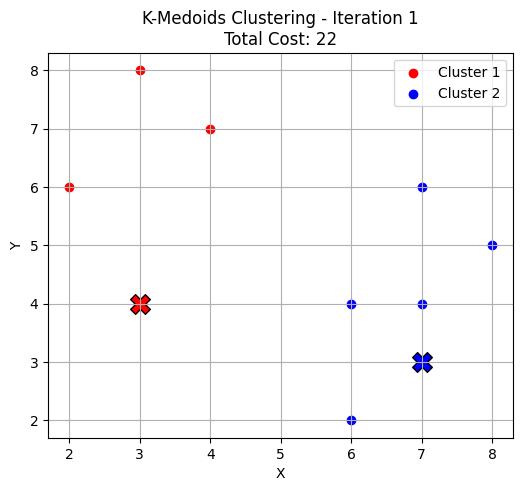


Iteration 2
Medoids: [[2, 6], [7, 3]]
Cluster Assignments:
  A1 [2, 6] -> Distances: [0, 8] -> Assigned to Cluster 1
  A2 [3, 8] -> Distances: [3, 9] -> Assigned to Cluster 1
  A3 [4, 7] -> Distances: [3, 7] -> Assigned to Cluster 1
  A4 [6, 2] -> Distances: [8, 2] -> Assigned to Cluster 2
  A5 [6, 4] -> Distances: [6, 2] -> Assigned to Cluster 2
  A6 [7, 3] -> Distances: [8, 0] -> Assigned to Cluster 2
  A7 [7, 4] -> Distances: [7, 1] -> Assigned to Cluster 2
  A8 [8, 5] -> Distances: [7, 3] -> Assigned to Cluster 2
  A9 [7, 6] -> Distances: [5, 3] -> Assigned to Cluster 2
  A10 [3, 4] -> Distances: [3, 5] -> Assigned to Cluster 1
Total Cost: 20


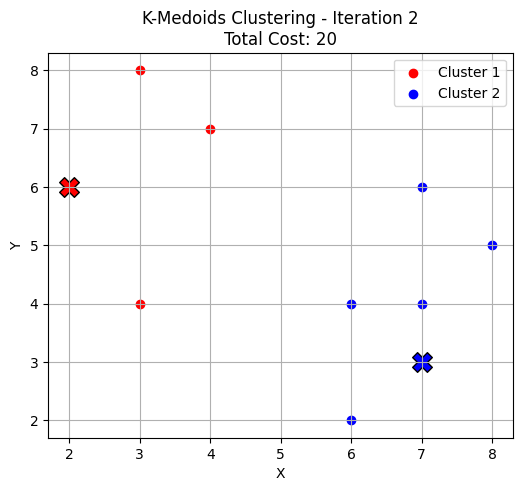


Iteration 3
Medoids: [[2, 6], [7, 4]]
Cluster Assignments:
  A1 [2, 6] -> Distances: [0, 7] -> Assigned to Cluster 1
  A2 [3, 8] -> Distances: [3, 8] -> Assigned to Cluster 1
  A3 [4, 7] -> Distances: [3, 6] -> Assigned to Cluster 1
  A4 [6, 2] -> Distances: [8, 3] -> Assigned to Cluster 2
  A5 [6, 4] -> Distances: [6, 1] -> Assigned to Cluster 2
  A6 [7, 3] -> Distances: [8, 1] -> Assigned to Cluster 2
  A7 [7, 4] -> Distances: [7, 0] -> Assigned to Cluster 2
  A8 [8, 5] -> Distances: [7, 2] -> Assigned to Cluster 2
  A9 [7, 6] -> Distances: [5, 2] -> Assigned to Cluster 2
  A10 [3, 4] -> Distances: [3, 4] -> Assigned to Cluster 1
Total Cost: 18


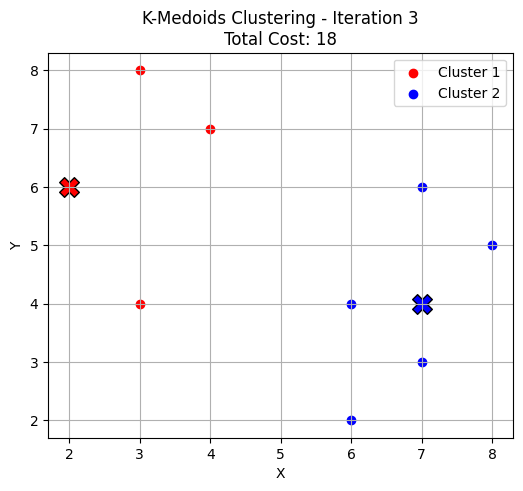


Converged at iteration 3 with total cost 18


In [ ]:
# Task 3.6: Run K-Medoids until convergence
iteration = 1
while True:
    clusters, cost, assignments = assign_clusters(points, medoids)      # Assign the clusters
    print(f"\nIteration {iteration}")
    print(f"Medoids: {[medoid.tolist() for medoid in medoids]}")
    print("Cluster Assignments:")

    # Loop through each point in assignments
    for idx, coords, distances, cluster in assignments:
        formatted_distances = [int(d) for d in distances]
        print(f"  A{idx} {coords} -> Distances: {formatted_distances} -> Assigned to Cluster {cluster}")
    print(f"Total Cost: {cost}")

    plot_clusters(points, clusters, medoids, iteration, cost)       # Plot the clusters and medoids
    new_medoids, new_cost = try_swaps(points, medoids, cost)        # Try to get better medoids and better cost

    if np.array_equal(new_medoids, medoids):       # Check if the medoids are updated
        print(f"\nConverged at iteration {iteration} with total cost {cost}")
        break
    medoids = new_medoids     # Update the medoids
    iteration += 1      # Update the iteration number